### Data Import Test

Number of files in the dataset folder:  9
Logistic Regression - Sag - Iterations: [12]


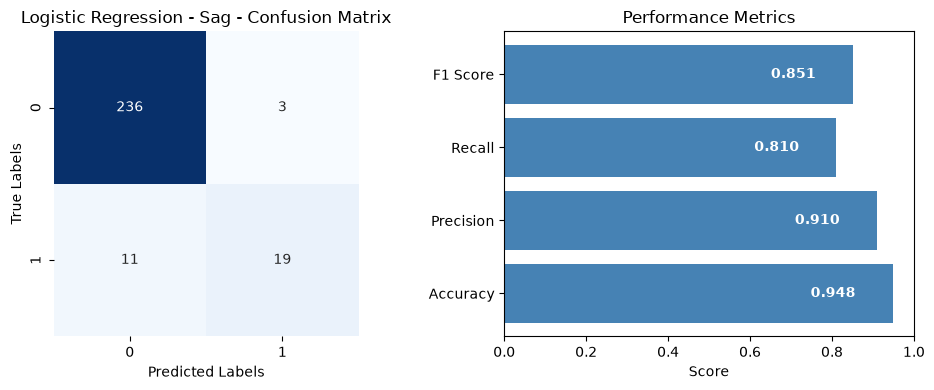

AttributeError: 'DataFrame' object has no attribute 'append'

In [10]:
from import_data import data_import
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from classifier import Classifier
import matplotlib.pyplot as plt
import pandas as pd

files = ["SNR_noiseless"]

features_sag = ["F1", "F2", "F7", "F8"]
feature_sag_harm = ["F1", "F2", "F7"]
features_tran = ["F1", "F7"]
features_swell_harm = ["F1", "F2", "F7"]
features_normal = ["F1", "F5"]
features_flicker = ["F1", "F2", "F4", "F8"]
features_harmonics = ["F1", "F4", "F5", "F7"]
features_swell = ["F3", "F4", "F7"]
features_interruptions = ["F8"]

target_labels = ["Sag", "Sag_harmonics", "Transient", "Swell_harmonics", "Normal", "Flicker", "Harmonics", "Swell", "Interruption"]
feature_sets = [features_sag, feature_sag_harm, features_tran, features_swell_harm, features_normal, features_flicker, features_harmonics, features_swell, features_interruptions]

score_rows = []

for target_label, features in zip(target_labels, feature_sets):
    data, sample_labels = data_import(files, features)
    full_data = pd.DataFrame(data, columns=features)

    # Change labels to binary classification: 1 for the target class, 0 for all other events
    binary_labels = [int(sample_label == target_label) for sample_label in sample_labels]

    # add labels to the dataframe
    full_data['Label'] = binary_labels

    X_train, X_test, y_train, y_test = train_test_split(data, binary_labels, test_size=0.2, random_state=42, stratify=binary_labels)

    logistic_regression = LogisticRegression()

    metrics = Classifier(logistic_regression, X_train, y_train, X_test, y_test, title="Logistic Regression - " + target_label)

    # Add the results to the score list
    score_rows.append({"Target Label": target_label, **metrics})

score_list = pd.DataFrame(score_rows)
print(score_list)